# Unified Random Forest Training — All 32 Neuromorphic Models

Trains models for all 4 dataset configurations:
- **Routed** (`SpikeN_*`) → 8 neuron types → `model_route_node/`
- **Blind** (`SpikeB_*`) → 8 neuron types → `model_blind/`
- **BlindDir** (`SpikeBD_*`) → 8 neuron types → `model_blind_dir/`
- **BlindSum** (`SpikeB_*`) → 8 neuron types → sum of N1–N5 into single feature

**Total: 4 × 8 = 32 models**

Each model is trained with **GridSearchCV** (5-fold stratified CV).

## 1. Imports & Configuration

In [38]:
import os, glob, re
import pandas as pd
import numpy as np
from io import StringIO
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# Inline plots
%matplotlib inline
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

In [39]:
# --- Paths ---
NOTEBOOK_DIR = os.path.abspath('')
DATASET_DIR = os.path.join(NOTEBOOK_DIR, "Dataset")

# Feature column definitions
NEURON_COLS_5CH = ['N1', 'N2', 'N3', 'N4', 'N5']
NEURON_COLS_11CH = [
    'N1', 'N2', 'N3', 'N4', 'N5',
    'dir_x_pos', 'dir_y_pos', 'dir_z_pos',
    'dir_x_neg', 'dir_y_neg', 'dir_z_neg'
]
NEURON_COLS_1CH = ['N_sum']

# Training configurations
TRAIN_CONFIGS = [
    {
        'label':        'Routed',
        'data_dir':     os.path.join(DATASET_DIR, 'Routed'),
        'prefix':       'SpikeN_',
        'features':     NEURON_COLS_5CH,
        'n_features':   5,
        'color':        '#2980b9',
    },
    {
        'label':        'Blind',
        'data_dir':     os.path.join(DATASET_DIR, 'Blind'),
        'prefix':       'SpikeB_',
        'features':     NEURON_COLS_5CH,
        'n_features':   5,
        'color':        '#27ae60',
    },
    {
        'label':        'BlindDir',
        'data_dir':     os.path.join(DATASET_DIR, 'BlindDir'),
        'prefix':       'SpikeBD_',
        'features':     NEURON_COLS_11CH,
        'n_features':   11,
        'color':        '#8e44ad',
    },
    {
        'label':        'BlindSum',
        'data_dir':     os.path.join(DATASET_DIR, 'Blind'),
        'prefix':       'SpikeB_',
        'features':     NEURON_COLS_1CH,
        'n_features':   1,
        'color':        '#e67e22',
    },
]

# Hyperparameter grid for GridSearchCV
PARAM_GRID = {
    'n_estimators':     [50, 100, 200],
    'max_depth':        [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
}

n_comb = 1
for v in PARAM_GRID.values():
    n_comb *= len(v)

print(f'Total HP combinations per neuron: {n_comb}')
print(f'Trainings per neuron (x5 fold):   {n_comb * 5}')
print(f'Total models to train:            {len(TRAIN_CONFIGS)} configs × 8 neurons = {len(TRAIN_CONFIGS) * 8}')

Total HP combinations per neuron: 36
Trainings per neuron (x5 fold):   180
Total models to train:            4 configs × 8 neurons = 32


## 2. Utility Functions

In [40]:
def fix_decimal_commas(filepath):
    """Fixes CSV file with decimal comma (15 raw columns -> 8 real columns).

    Some CSV files exported from LabVIEW use commas as decimal separators,
    resulting in 15 columns instead of 8. This function merges pairs of
    columns back into proper decimal numbers.

    Returns the fixed lines as a list of strings, or None if no fix is needed.
    """
    with open(filepath, 'r') as f:
        lines = f.readlines()
    if not lines:
        return None
    n_cols = len(lines[0].strip().split(','))
    if n_cols == 15:
        new_lines = []
        for line in lines:
            p = line.strip().split(',')
            row = (f'{p[0]}.{p[1]},{p[2]},'
                   f'{p[3]}.{p[4]},{p[5]}.{p[6]},{p[7]}.{p[8]},'
                   f'{p[9]}.{p[10]},{p[11]}.{p[12]},{p[13]}.{p[14]}')
            new_lines.append(row)
        return new_lines
    return None


def extract_neuron_name(filename):
    """Extracts the neuron type from the filename.

    Handles all known prefixes: SpikeBD_, SpikeB_, SpikeN_, SpikeT_, Spike_
    """
    basename = os.path.basename(filename).replace('.csv', '')
    for prefix in ['SpikeBD_', 'SpikeB_', 'SpikeN_', 'SpikeT_', 'Spike_']:
        if basename.startswith(prefix):
            rest = basename[len(prefix):]
            break
    else:
        return basename
    parts = rest.split('_')
    if len(parts) >= 2:
        return '_'.join(parts[1:])
    # Case without underscore after timestamp (e.g. '...091815Fast')
    m = re.search(r'\d+(.+)', rest)
    return m.group(1) if m else rest


def load_spike_dataset_5ch(filepath):
    """Loads a 5-channel spike dataset (Routed or Blind).

    Expected format: 8 columns
        timestamp, label, N1, N2, N3, N4, N5, sum

    Returns a DataFrame with label + N1-N5.
    """
    col_names = ['timestamp', 'label', 'N1', 'N2', 'N3', 'N4', 'N5', 'sum']
    fixed = fix_decimal_commas(filepath)
    try:
        if fixed is not None:
            text = chr(10).join(fixed)
            df = pd.read_csv(StringIO(text), header=None, names=col_names)
        else:
            df = pd.read_csv(filepath, header=None, names=col_names)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=col_names)
    df = df.dropna()
    df = df.drop(columns=['timestamp', 'sum'])
    df['label'] = df['label'].astype(int)
    return df


def load_spike_dataset_11ch(filepath):
    """Loads an 11-channel spike dataset (BlindDir).

    Expected format: 14 columns
        timestamp, label, N1..N5, dir_x_pos, dir_y_pos, dir_z_pos,
        dir_x_neg, dir_y_neg, dir_z_neg, sum

    Returns a DataFrame with label + 11 feature columns.
    """
    col_names = [
        'timestamp', 'label',
        'N1', 'N2', 'N3', 'N4', 'N5',
        'dir_x_pos', 'dir_y_pos', 'dir_z_pos',
        'dir_x_neg', 'dir_y_neg', 'dir_z_neg',
        'sum'
    ]
    fixed = fix_decimal_commas(filepath)
    try:
        if fixed is not None:
            text = chr(10).join(fixed)
            df = pd.read_csv(StringIO(text), header=None, names=col_names)
        else:
            df = pd.read_csv(filepath, header=None, names=col_names)
    except pd.errors.EmptyDataError:
        return pd.DataFrame(columns=col_names)
    df = df.dropna()
    df = df.drop(columns=['timestamp', 'sum'])
    df['label'] = df['label'].astype(int)
    return df


def load_spike_dataset_1ch_sum(filepath):
    """Loads a 5-channel spike dataset and sums N1..N5 into a single feature.

    Uses the same Blind CSV format (8 columns) but returns label + N_sum,
    where N_sum = N1 + N2 + N3 + N4 + N5.

    Returns a DataFrame with label + N_sum.
    """
    df = load_spike_dataset_5ch(filepath)
    if df.empty:
        return df
    df['N_sum'] = df[['N1', 'N2', 'N3', 'N4', 'N5']].sum(axis=1)
    df = df.drop(columns=['N1', 'N2', 'N3', 'N4', 'N5'])
    return df

## 3. Training Function

In [41]:
def train_models(data_dir, config_label, spike_prefix, neuron_cols, n_features):
    """Grid Search + train for each neuron CSV in the directory.

    Returns
    -------
    results : list[dict]
        List of result dictionaries, one per trained model.
    """
    # Select the appropriate loader based on feature count
    if n_features == 11:
        load_fn = load_spike_dataset_11ch
    elif n_features == 1:
        load_fn = load_spike_dataset_1ch_sum
    else:
        load_fn = load_spike_dataset_5ch

    files = sorted(glob.glob(os.path.join(data_dir, spike_prefix + '*.csv')))
    if not files:
        print(f'  WARNING: No files found matching {spike_prefix}*.csv in {data_dir}')
        return []

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    results = []

    for filepath in files:
        name = extract_neuron_name(filepath)
        df = load_fn(filepath)
        if len(df) < 5:
            print(f'  Skipping {name} due to insufficient samples ({len(df)}).')
            continue
        X = df[neuron_cols].values
        y = df['label'].values

        # Grid Search with double scoring
        grid = GridSearchCV(
            estimator=RandomForestClassifier(
                random_state=42, n_jobs=-1, class_weight='balanced'),
            param_grid=PARAM_GRID,
            cv=skf,
            scoring={'accuracy': 'accuracy', 'f1': 'f1_macro'},
            refit='accuracy',
            n_jobs=-1,
            return_train_score=False
        )
        grid.fit(X, y)

        bp = grid.best_params_
        bi = grid.best_index_
        acc_mean = grid.cv_results_['mean_test_accuracy'][bi]
        acc_std  = grid.cv_results_['std_test_accuracy'][bi]
        f1_mean  = grid.cv_results_['mean_test_f1'][bi]
        f1_std   = grid.cv_results_['std_test_f1'][bi]

        # Final model retrained on the whole dataset with best params
        rf_final = RandomForestClassifier(
            **bp, random_state=42, n_jobs=-1, class_weight='balanced')
        rf_final.fit(X, y)

        depth_str = str(bp['max_depth']) if bp['max_depth'] is not None else 'None'
        print(f'  {name:<20s} | Acc: {acc_mean:.4f} \u00b1 {acc_std:.4f} | '
              f'F1: {f1_mean:.4f} | '
              f'n_est={bp["n_estimators"]:>3}, depth={depth_str:<4}, '
              f'split={bp["min_samples_split"]}, leaf={bp["min_samples_leaf"]}')

        results.append({
            'Neuron': name, 'Config': config_label,
            'Accuracy': acc_mean, 'Acc_Std': acc_std,
            'F1_Macro': f1_mean, 'F1_Std': f1_std,
            'n_estimators': bp['n_estimators'],
            'max_depth': bp['max_depth'],
            'min_samples_split': bp['min_samples_split'],
            'min_samples_leaf': bp['min_samples_leaf'],
            'Samples': len(df)
        })

    return results

## 4. Plotting Functions

In [42]:
def get_vals(df, col, neurons):
    """Extract values from df for a given column, aligned to a neuron list."""
    return [df[df['Neuron'] == n][col].values[0]
            if n in df['Neuron'].values else 0 for n in neurons]


def plot_accuracy_comparison(all_dfs):
    """Bar chart comparing accuracy across all configurations and neuron types."""
    # Collect all unique neurons across all configs
    all_neurons = []
    for df in all_dfs.values():
        for n in df['Neuron'].tolist():
            if n not in all_neurons:
                all_neurons.append(n)

    n_configs = len(all_dfs)
    x = np.arange(len(all_neurons))
    w = 0.8 / n_configs  # bar width

    fig, ax = plt.subplots(figsize=(16, 8))

    for i, (label, df) in enumerate(all_dfs.items()):
        config = next(c for c in TRAIN_CONFIGS if c['label'] == label)
        acc = get_vals(df, 'Accuracy', all_neurons)
        std = get_vals(df, 'Acc_Std', all_neurons)
        offset = (i - n_configs / 2 + 0.5) * w
        bars = ax.bar(x + offset, acc, w, yerr=std,
                      label=f'{label} ({config["n_features"]}ch)',
                      color=config['color'], edgecolor='white',
                      capsize=3, alpha=0.9)
        for b, a in zip(bars, acc):
            if a > 0:
                ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.012,
                        f'{a:.3f}', ha='center', fontsize=7, fontweight='bold')

    ax.set_xticks(x)
    ax.set_xticklabels(all_neurons, rotation=45, ha='right', fontsize=11)
    ax.set_ylabel('Accuracy (5-Fold CV)', fontsize=12)
    ax.set_title('Accuracy Comparison per Neuron Type — All Configurations\n'
                 '(Optimized Grid Search)',
                 fontsize=14, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1/6, color='grey', ls='--', alpha=0.5, label='Chance (1/6)')
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


def plot_delta(df1, df2, label1, label2, neurons):
    """Bar chart showing accuracy delta between two configurations."""
    a1 = get_vals(df1, 'Accuracy', neurons)
    a2 = get_vals(df2, 'Accuracy', neurons)
    delta = [v1 - v2 for v1, v2 in zip(a1, a2)]

    fig, ax = plt.subplots(figsize=(12, 5))
    colors = ['#27ae60' if d >= 0 else '#c0392b' for d in delta]
    bars = ax.bar(neurons, delta, color=colors, edgecolor='white', alpha=0.85)
    for b, d in zip(bars, delta):
        va = 'bottom' if d >= 0 else 'top'
        off = 0.002 if d >= 0 else -0.008
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + off,
                f'{d:+.3f}', ha='center', va=va, fontsize=9, fontweight='bold')
    ax.axhline(y=0, color='black', lw=0.8)
    ax.set_ylabel(f'\u0394 Accuracy ({label1} \u2212 {label2})', fontsize=11)
    ax.set_title(f'Accuracy Delta: {label1} vs {label2}', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()

## 5. Train All Configurations

In [43]:
all_results = {}   # label -> list[dict]
all_dfs     = {}   # label -> DataFrame

for cfg in TRAIN_CONFIGS:
    print('=' * 80)
    print(f'  GRID SEARCH + TRAINING — {cfg["label"].upper()} '
          f'({cfg["n_features"]} features, prefix={cfg["prefix"]})')
    print(f'  Dataset: {cfg["data_dir"]}')
    print('=' * 80)
    print()

    results = train_models(
        data_dir=cfg['data_dir'],
        config_label=cfg['label'],
        spike_prefix=cfg['prefix'],
        neuron_cols=cfg['features'],
        n_features=cfg['n_features'],
    )

    all_results[cfg['label']] = results
    if results:
        df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
        all_dfs[cfg['label']] = df
        print(f'\n\u2714 {len(results)} models trained for {cfg["label"]}')
    else:
        print(f'\n\u2718 No models trained for {cfg["label"]}')
    print()

  GRID SEARCH + TRAINING — ROUTED (5 features, prefix=SpikeN_)
  Dataset: c:\Users\ricca\OneDrive - University of Pisa\Andrea Diano's files - HMC Neuromorphic Project\Final_Lab\Python\Dataset\Routed

  Chattering           | Acc: 0.9716 ± 0.0168 | F1: 0.9717 | n_est=200, depth=None, split=2, leaf=1
  Fast                 | Acc: 0.9754 ± 0.0113 | F1: 0.9755 | n_est=100, depth=10  , split=2, leaf=1
  IntrinsicallyB       | Acc: 0.9678 ± 0.0128 | F1: 0.9679 | n_est=200, depth=None, split=2, leaf=1
  Low-Threshold        | Acc: 0.9716 ± 0.0146 | F1: 0.9717 | n_est= 50, depth=None, split=2, leaf=1
  Regular              | Acc: 0.9716 ± 0.0133 | F1: 0.9715 | n_est=100, depth=10  , split=2, leaf=1
  Resonator            | Acc: 0.9735 ± 0.0110 | F1: 0.9736 | n_est=100, depth=None, split=2, leaf=1
  Thalamo1             | Acc: 0.9640 ± 0.0109 | F1: 0.9641 | n_est=100, depth=10  , split=2, leaf=1
  Thalamo2             | Acc: 0.9716 ± 0.0133 | F1: 0.9715 | n_est=100, depth=10  , split=2, leaf=1


## 6. Summary

In [44]:
total_models = sum(len(r) for r in all_results.values())
print(f'Training complete — {total_models} / {len(TRAIN_CONFIGS) * 8} models')
print()

if all_dfs:
    df_all = pd.concat(all_dfs.values(), ignore_index=True)
    display(df_all[['Neuron', 'Config', 'Accuracy', 'Acc_Std', 'F1_Macro', 'F1_Std',
                     'n_estimators', 'max_depth', 'Samples']])

Training complete — 32 / 32 models



,Neuron,Config,Accuracy,Acc_Std,F1_Macro,F1_Std,n_estimators,max_depth,Samples
0,Fast,Routed,0.975400,0.011285,0.975459,0.011305,100,10.0,528
1,Resonator,Routed,0.973513,0.010953,0.973622,0.011013,100,NaN,528
2,Regular,Routed,0.971626,0.013317,0.971455,0.013580,100,10.0,528
3,Chattering,Routed,0.971626,0.016836,0.971712,0.016807,200,NaN,528
4,Thalamo2,Routed,0.971626,0.013317,0.971455,0.013580,100,10.0,528
5,Low-Threshold,Routed,0.971608,0.014592,0.971709,0.014607,50,NaN,528
6,IntrinsicallyB,Routed,0.967817,0.012766,0.967876,0.012624,200,NaN,528
7,Thalamo1,Routed,0.964043,0.010928,0.964073,0.010772,100,10.0,528
8,Resonator,Blind,0.884492,0.006694,0.884835,0.008116,50,NaN,528
9,Regular,Blind,0.871285,0.015956,0.873770,0.016925,200,NaN,528


## 7. Accuracy Comparison — All Configurations

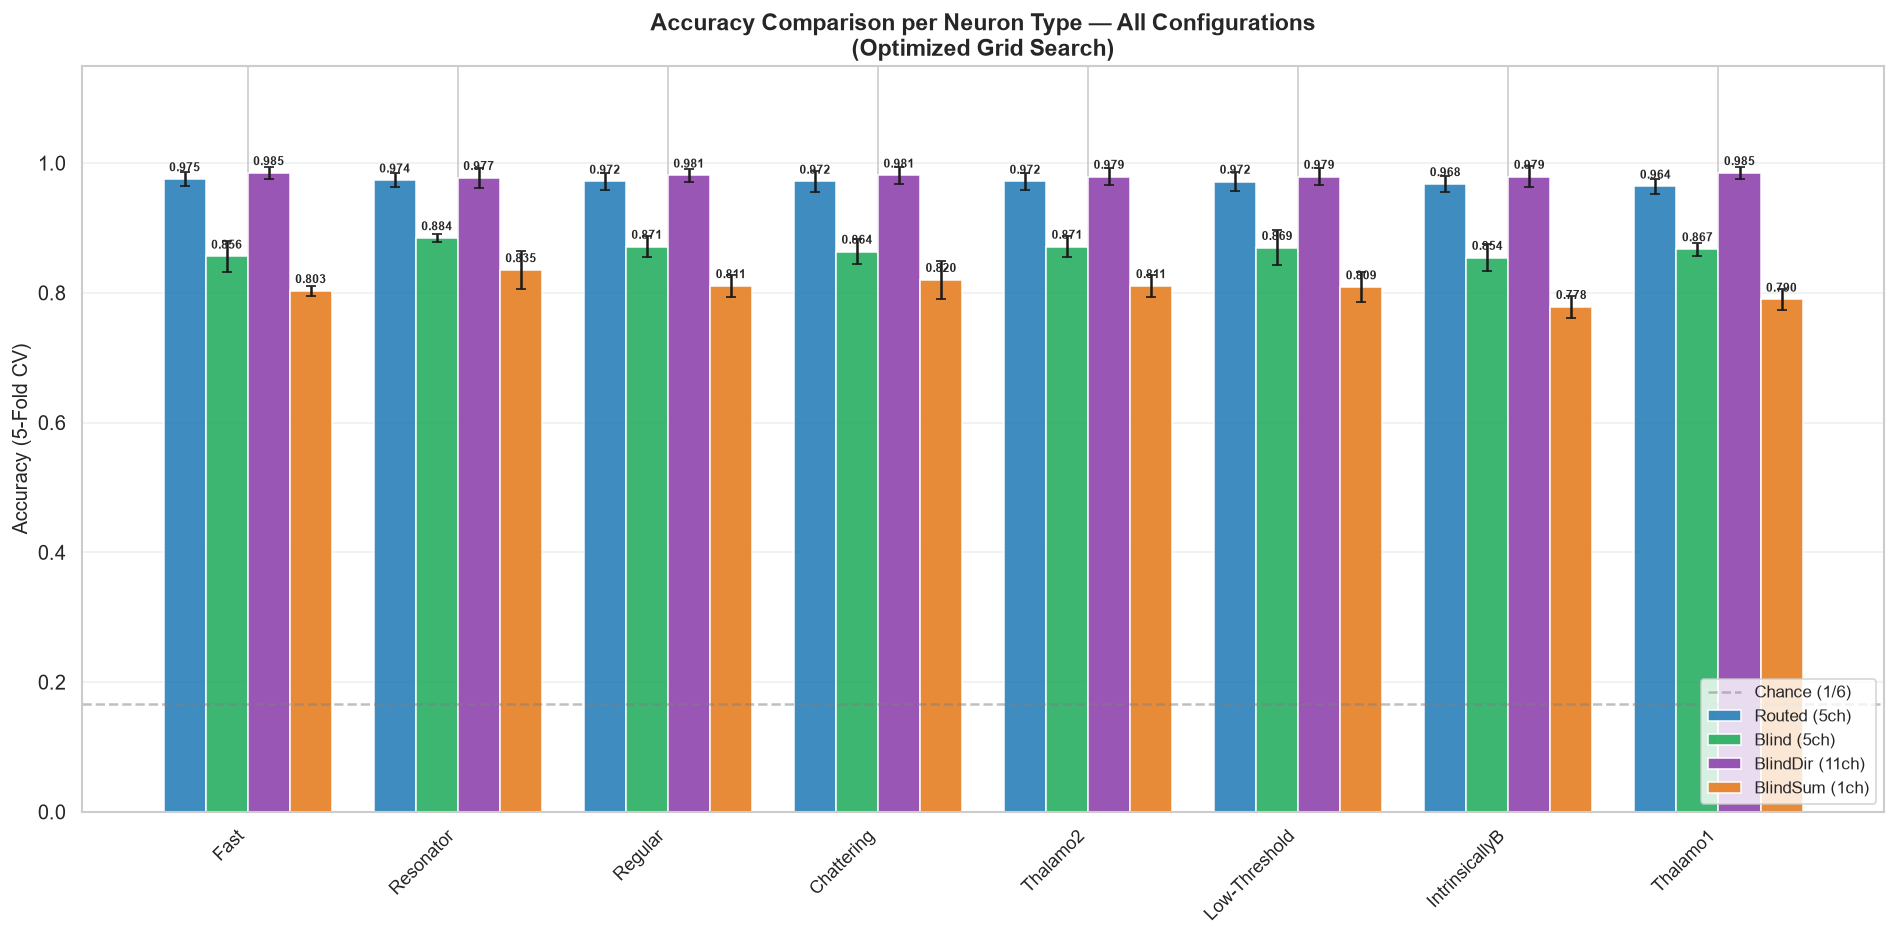

In [45]:
if len(all_dfs) > 0:
    plot_accuracy_comparison(all_dfs)

## 8. Delta Plots — Pairwise Configuration Comparison

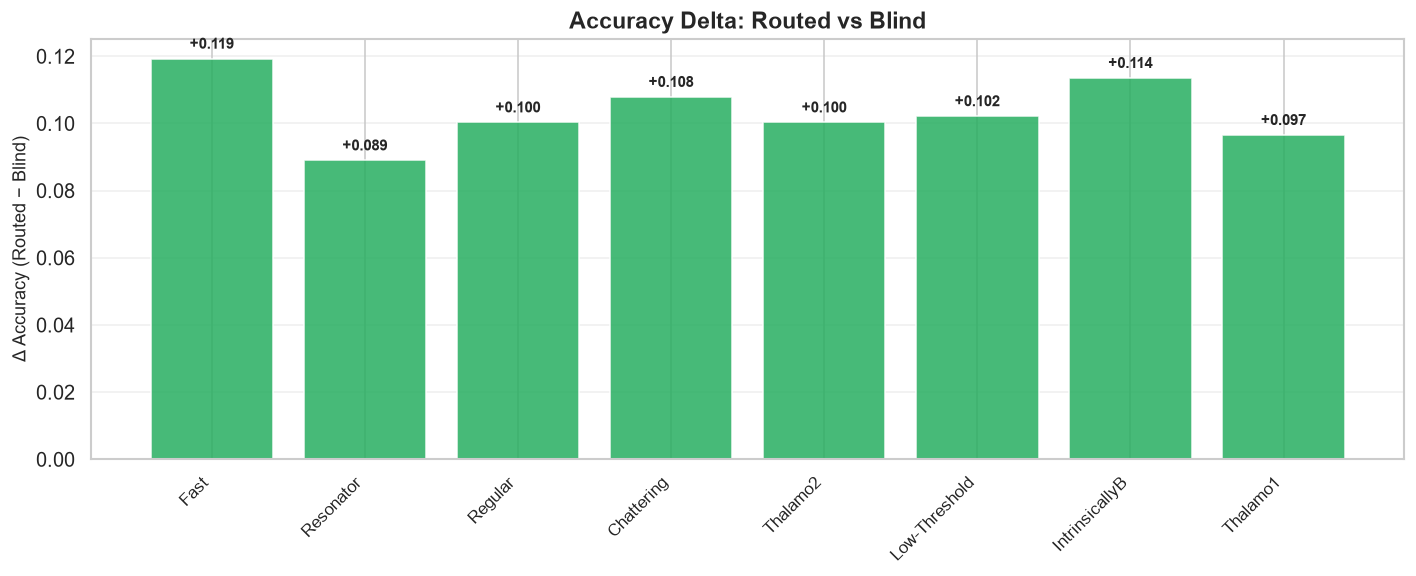

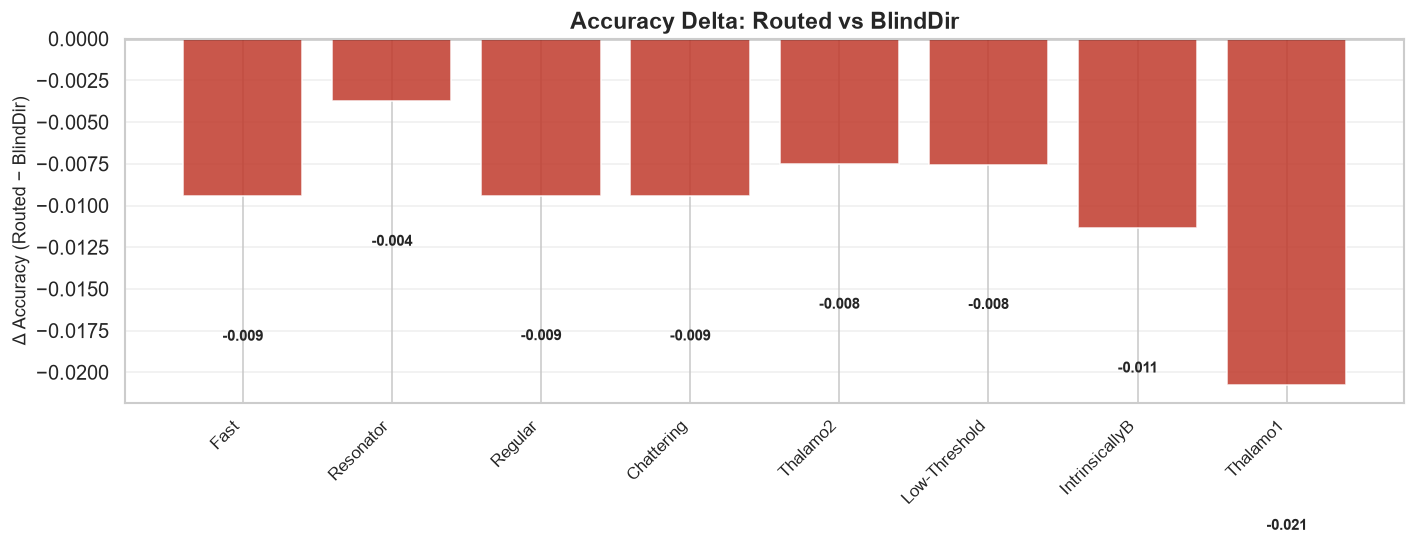

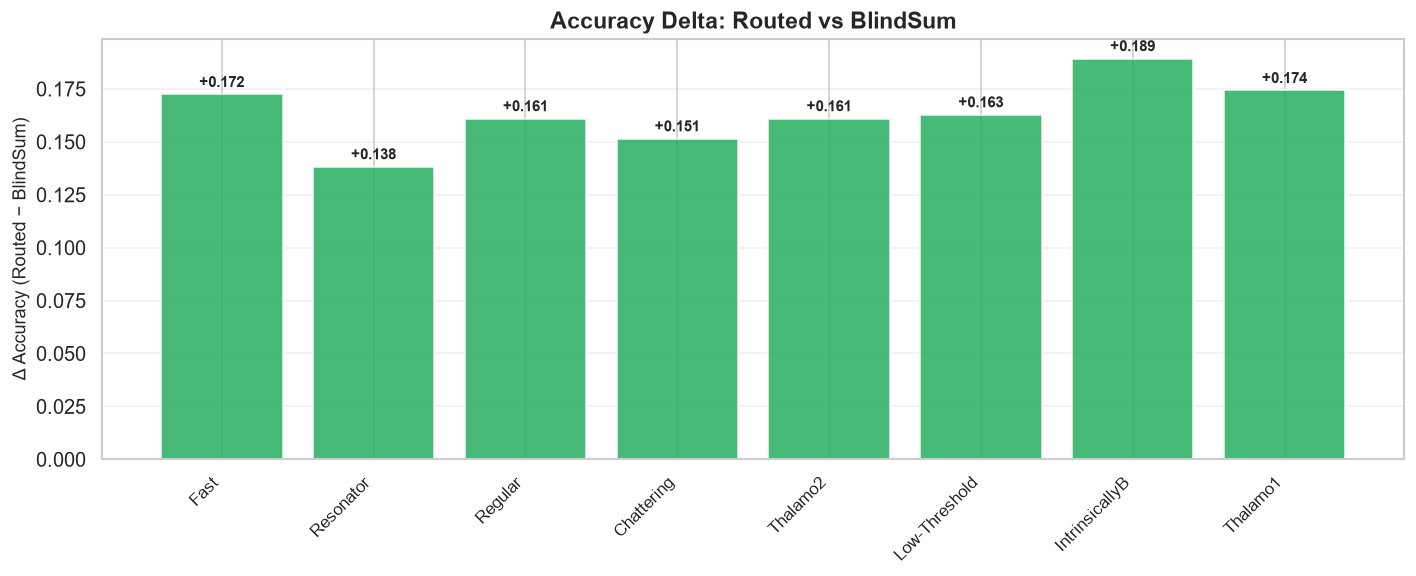

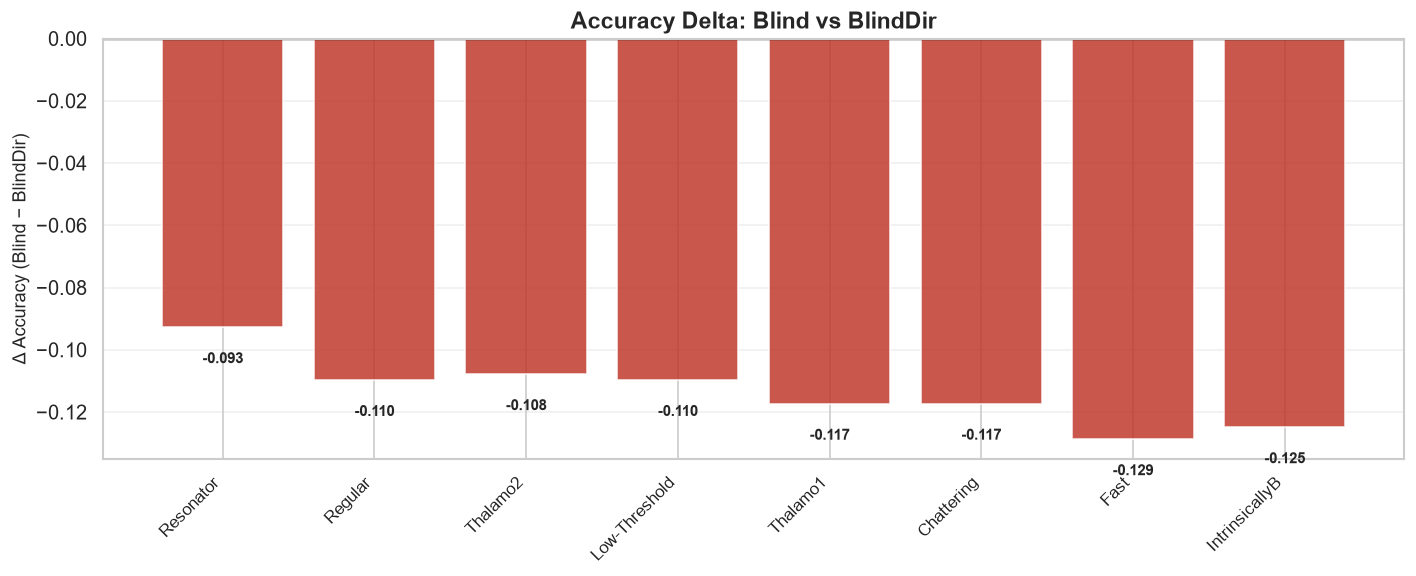

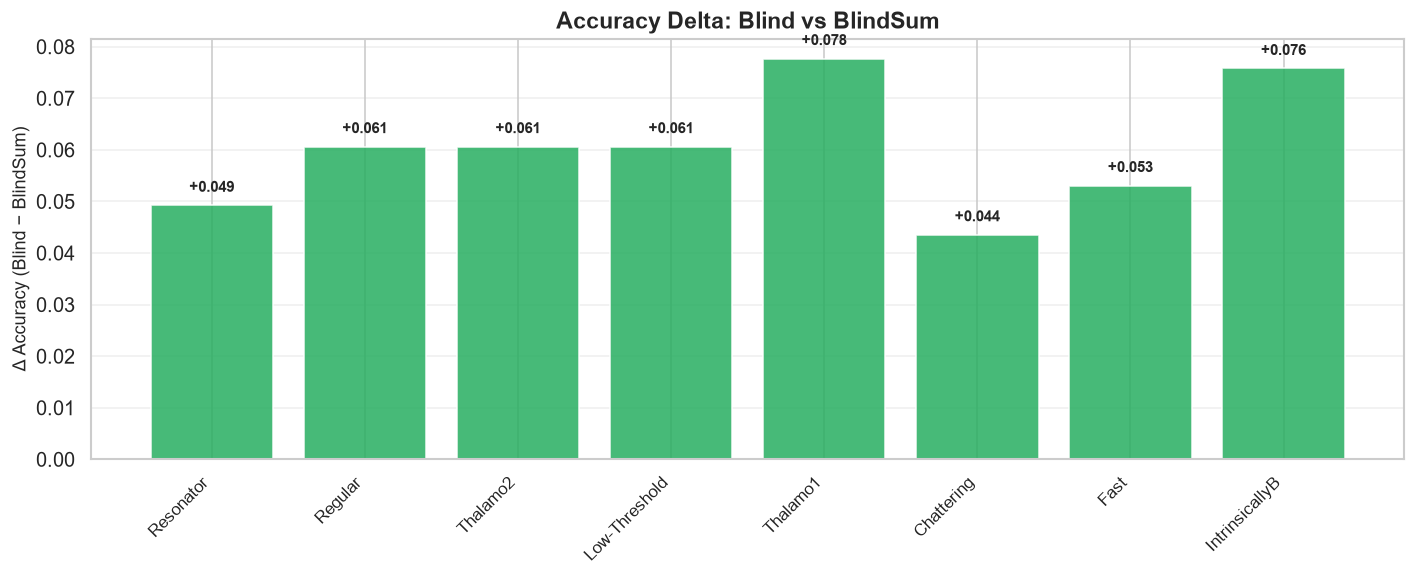

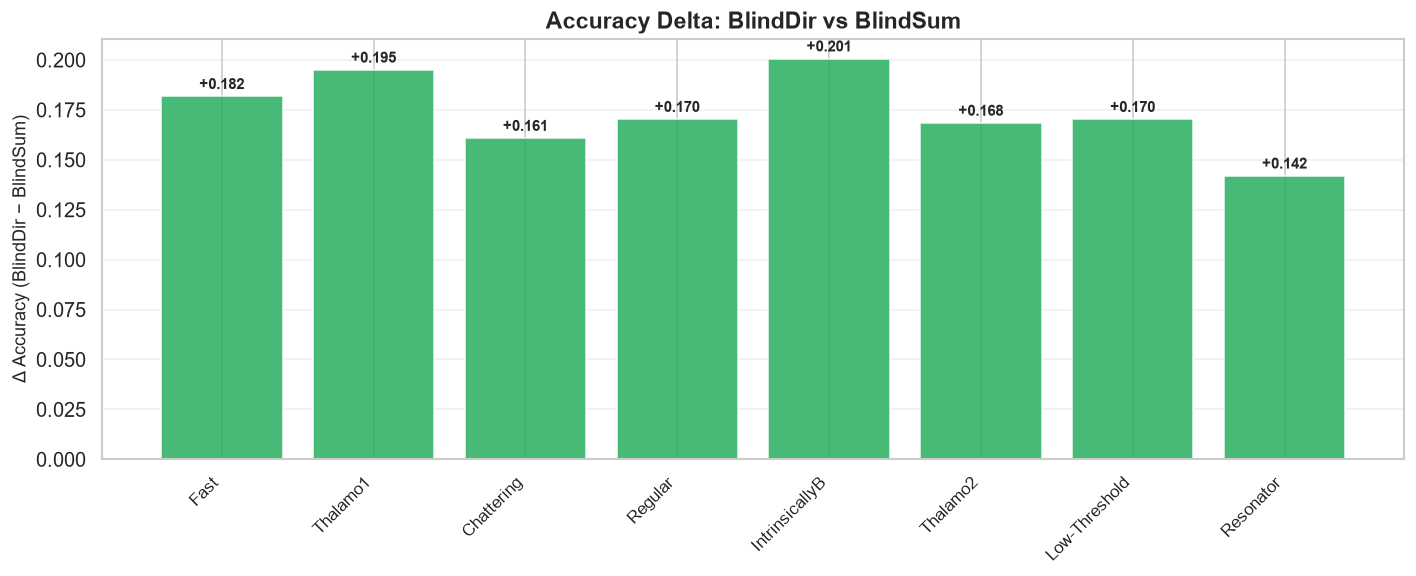


✔ All done!


In [46]:
if len(all_dfs) > 1:
    labels = list(all_dfs.keys())
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            l1, l2 = labels[i], labels[j]
            # Use union of neurons from both configs
            neurons = list(dict.fromkeys(
                all_dfs[l1]['Neuron'].tolist() + all_dfs[l2]['Neuron'].tolist()
            ))
            plot_delta(all_dfs[l1], all_dfs[l2], l1, l2, neurons)

print('\n\u2714 All done!')

## 9. Accuracy Heatmap — Configuration × Neuron Type

A heatmap view that makes it easy to spot which combinations perform best (green) vs worst (red).

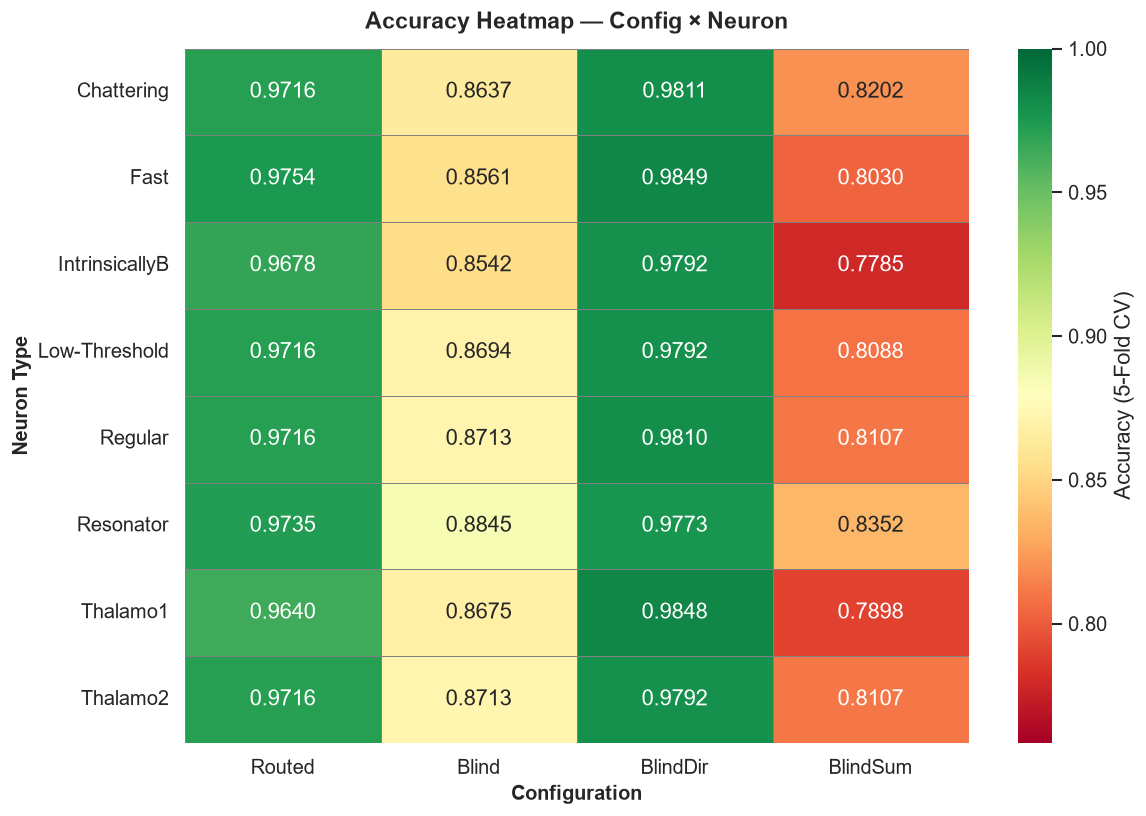

In [47]:
if all_dfs:
    # Pivot: rows = neuron types, columns = configurations
    df_all = pd.concat(all_dfs.values(), ignore_index=True)
    pivot = df_all.pivot_table(index='Neuron', columns='Config',
                               values='Accuracy', aggfunc='first')

    # Reorder columns to match TRAIN_CONFIGS order
    col_order = [c['label'] for c in TRAIN_CONFIGS if c['label'] in pivot.columns]
    pivot = pivot[col_order]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn',
                vmin=pivot.values.min() - 0.02, vmax=1.0,
                linewidths=0.6, linecolor='gray',
                cbar_kws={'label': 'Accuracy (5-Fold CV)'},
                ax=ax)
    ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Neuron Type', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy Heatmap — Config × Neuron',
                 fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

## 10. F1 Macro Heatmap — Configuration × Neuron Type

Same heatmap but for the F1 Macro score.

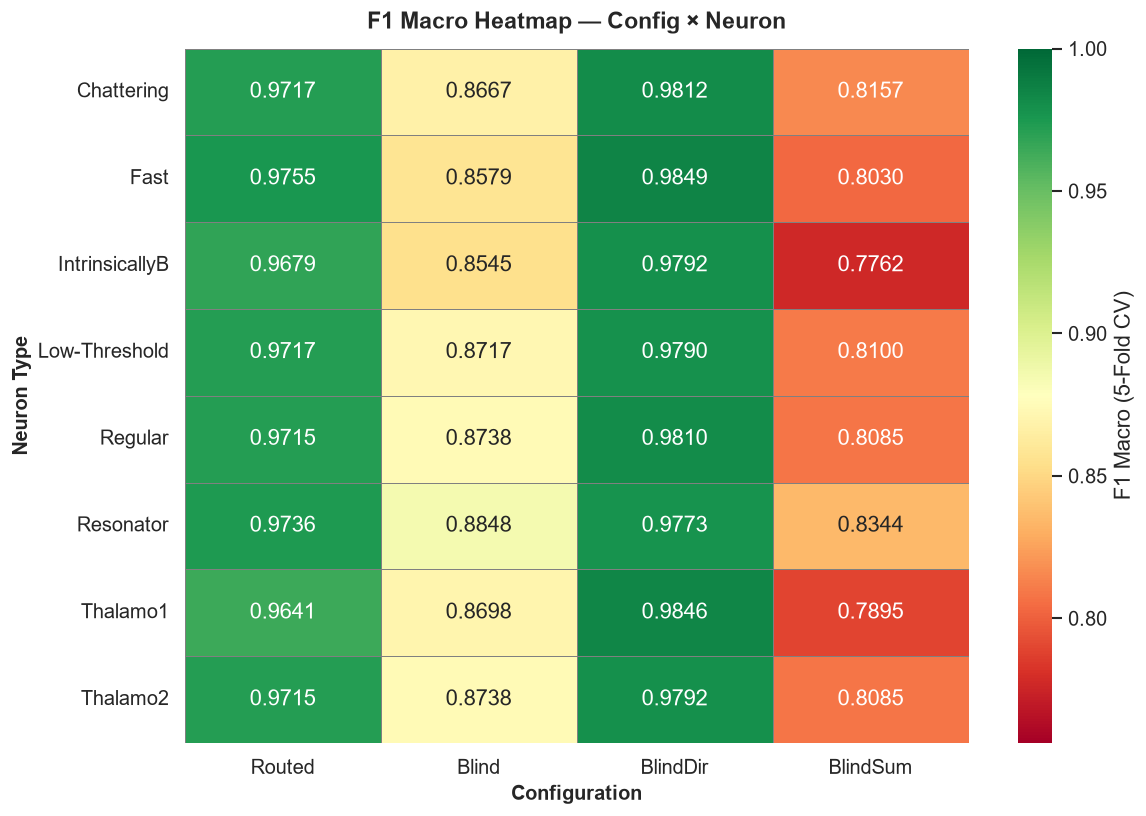

In [48]:
if all_dfs:
    pivot_f1 = df_all.pivot_table(index='Neuron', columns='Config',
                                   values='F1_Macro', aggfunc='first')
    pivot_f1 = pivot_f1[[c['label'] for c in TRAIN_CONFIGS if c['label'] in pivot_f1.columns]]

    fig, ax = plt.subplots(figsize=(10, 7))
    sns.heatmap(pivot_f1, annot=True, fmt='.4f', cmap='RdYlGn',
                vmin=pivot_f1.values.min() - 0.02, vmax=1.0,
                linewidths=0.6, linecolor='gray',
                cbar_kws={'label': 'F1 Macro (5-Fold CV)'},
                ax=ax)
    ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Neuron Type', fontsize=12, fontweight='bold')
    ax.set_title('F1 Macro Heatmap — Config × Neuron',
                 fontsize=14, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()

## 11. Accuracy Distribution per Configuration

How much variance is there across the 8 neuron types within each configuration?
A violin + strip plot reveals the distribution shape.

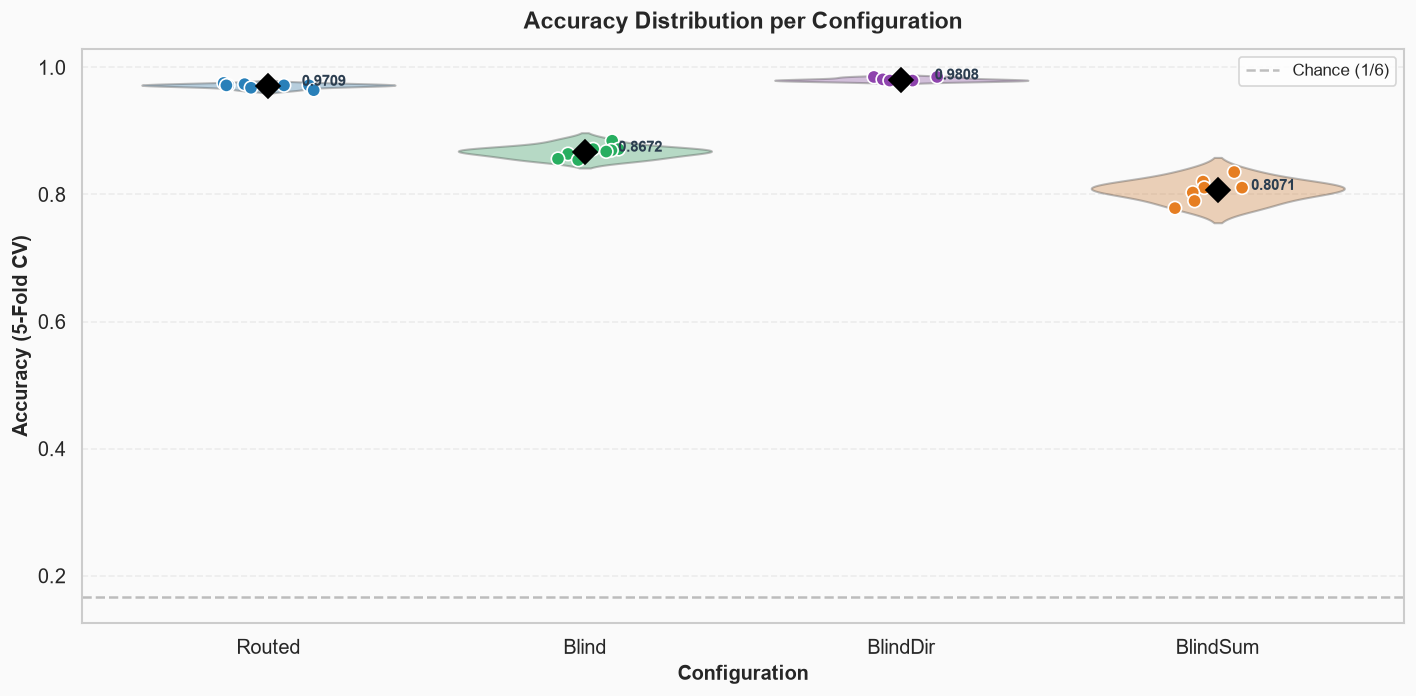

In [49]:
if all_dfs:
    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    config_colors = {c['label']: c['color'] for c in TRAIN_CONFIGS}
    palette = [config_colors[l] for l in col_order]

    sns.violinplot(data=df_all, x='Config', y='Accuracy',
                   order=col_order, palette=palette,
                   inner=None, alpha=0.35, ax=ax)
    sns.stripplot(data=df_all, x='Config', y='Accuracy',
                  order=col_order, palette=palette,
                  size=8, edgecolor='white', linewidth=1, jitter=0.15, ax=ax)

    # Mean markers
    for i, cfg in enumerate(col_order):
        sub = df_all[df_all['Config'] == cfg]
        mean_val = sub['Accuracy'].mean()
        ax.plot(i, mean_val, marker='D', color='black', markersize=10, zorder=5)
        ax.annotate(f'{mean_val:.4f}', (i, mean_val),
                    textcoords='offset points', xytext=(20, 0),
                    fontsize=9, fontweight='bold', color='#2c3e50')

    ax.set_xlabel('Configuration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy (5-Fold CV)', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy Distribution per Configuration',
                 fontsize=14, fontweight='bold', pad=12)
    ax.axhline(y=1/6, color='grey', ls='--', alpha=0.5, label='Chance (1/6)')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

## 12. Radar Chart — Accuracy per Neuron Across Configurations

A radar chart showing how each configuration performs on all 8 neuron types simultaneously.

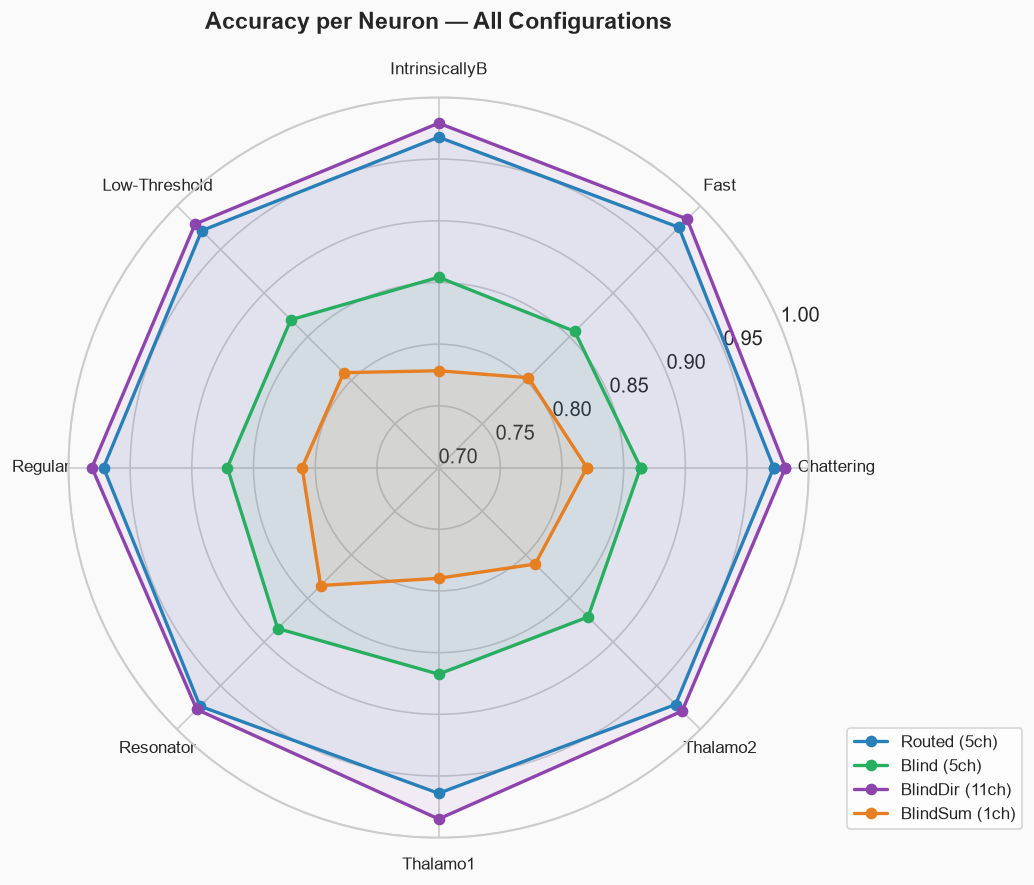

In [50]:
if all_dfs:
    from math import pi

    all_neurons = []
    for df in all_dfs.values():
        for n in df['Neuron'].tolist():
            if n not in all_neurons:
                all_neurons.append(n)
    all_neurons = sorted(all_neurons)

    N = len(all_neurons)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]  # close the polygon

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    for label, df in all_dfs.items():
        cfg = next(c for c in TRAIN_CONFIGS if c['label'] == label)
        values = []
        for n in all_neurons:
            row = df[df['Neuron'] == n]
            values.append(row['Accuracy'].values[0] if len(row) > 0 else 0)
        values += values[:1]
        ax.plot(angles, values, 'o-', linewidth=2, label=f"{label} ({cfg['n_features']}ch)",
                color=cfg['color'])
        ax.fill(angles, values, alpha=0.08, color=cfg['color'])

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(all_neurons, fontsize=10)
    ax.set_ylim(0.7, 1.0)
    ax.set_title('Accuracy per Neuron — All Configurations',
                 fontsize=14, fontweight='bold', pad=20)
    ax.legend(loc='lower right', bbox_to_anchor=(1.3, 0), fontsize=10)
    plt.tight_layout()
    plt.show()

## 13. Neuron Ranking per Configuration

Within each configuration, rank the neurons from best to worst. A bump chart style showing how neuron rankings shift across configurations.

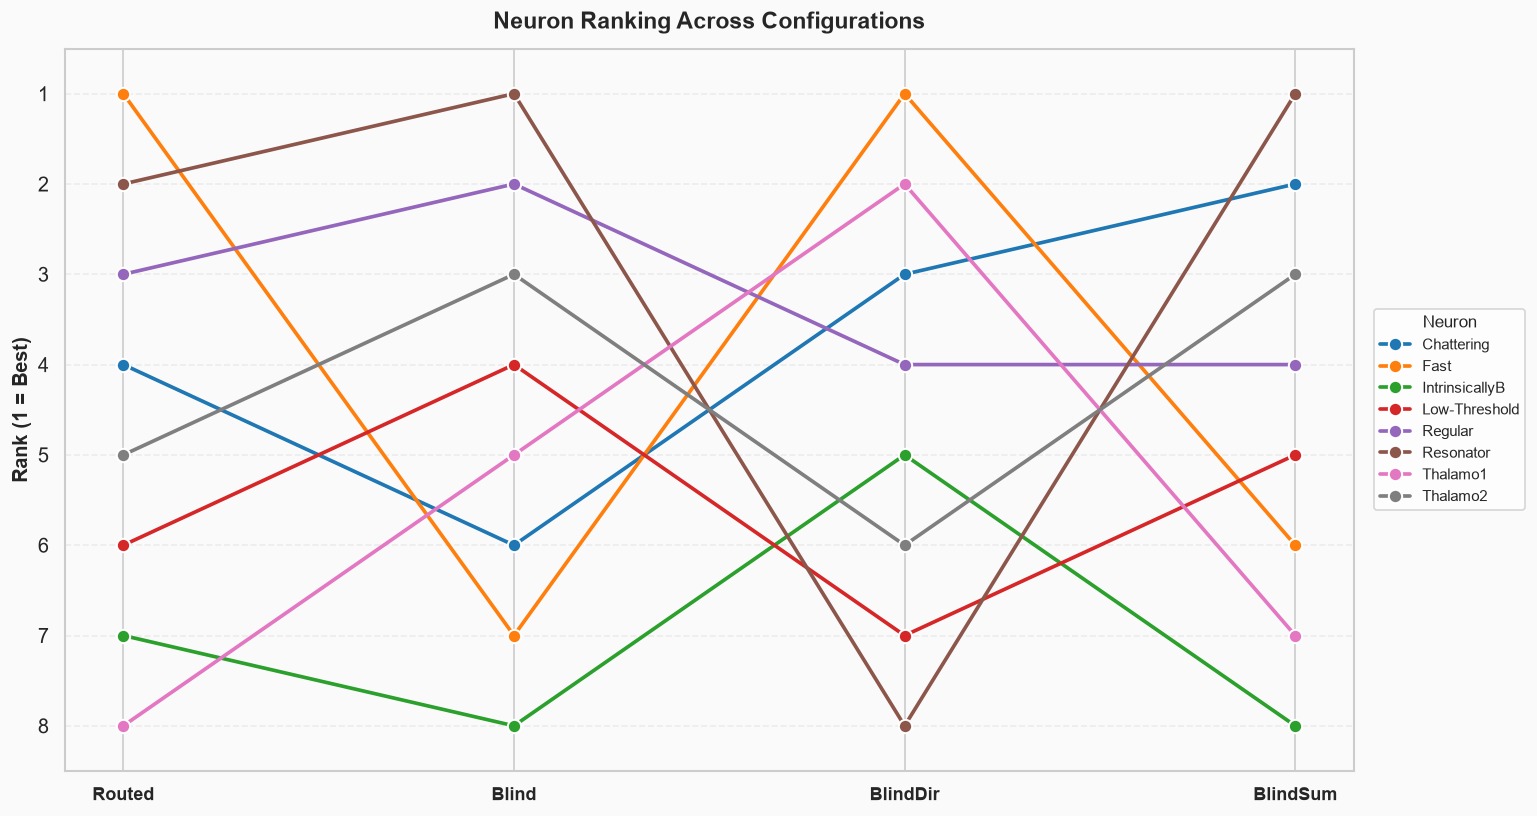

In [51]:
if all_dfs:
    fig, ax = plt.subplots(figsize=(13, 7))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    configs_list = [c['label'] for c in TRAIN_CONFIGS if c['label'] in all_dfs]
    n_configs = len(configs_list)
    neuron_colors = dict(zip(sorted(all_neurons),
                             sns.color_palette("tab10", len(all_neurons))))

    for neuron in sorted(all_neurons):
        ranks = []
        for cfg_label in configs_list:
            df = all_dfs[cfg_label]
            df_sorted = df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
            neurons_ranked = df_sorted['Neuron'].tolist()
            if neuron in neurons_ranked:
                ranks.append(neurons_ranked.index(neuron) + 1)
            else:
                ranks.append(None)

        x_positions = list(range(n_configs))
        valid = [(x, r) for x, r in zip(x_positions, ranks) if r is not None]
        if valid:
            xs, rs = zip(*valid)
            ax.plot(xs, rs, 'o-', linewidth=2.2, markersize=8,
                    label=neuron, color=neuron_colors[neuron],
                    markeredgecolor='white', markeredgewidth=1.2)

    ax.set_xticks(range(n_configs))
    ax.set_xticklabels(configs_list, fontsize=11, fontweight='bold')
    ax.set_ylabel('Rank (1 = Best)', fontsize=12, fontweight='bold')
    ax.set_title('Neuron Ranking Across Configurations',
                 fontsize=14, fontweight='bold', pad=12)
    ax.invert_yaxis()
    ax.set_ylim(len(all_neurons) + 0.5, 0.5)
    ax.set_yticks(range(1, len(all_neurons) + 1))
    ax.legend(title='Neuron', fontsize=9, title_fontsize=10,
              loc='center left', bbox_to_anchor=(1.01, 0.5))
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()

## 14. Best Hyperparameter Distribution

What hyperparameters does GridSearchCV prefer across all 32 models?

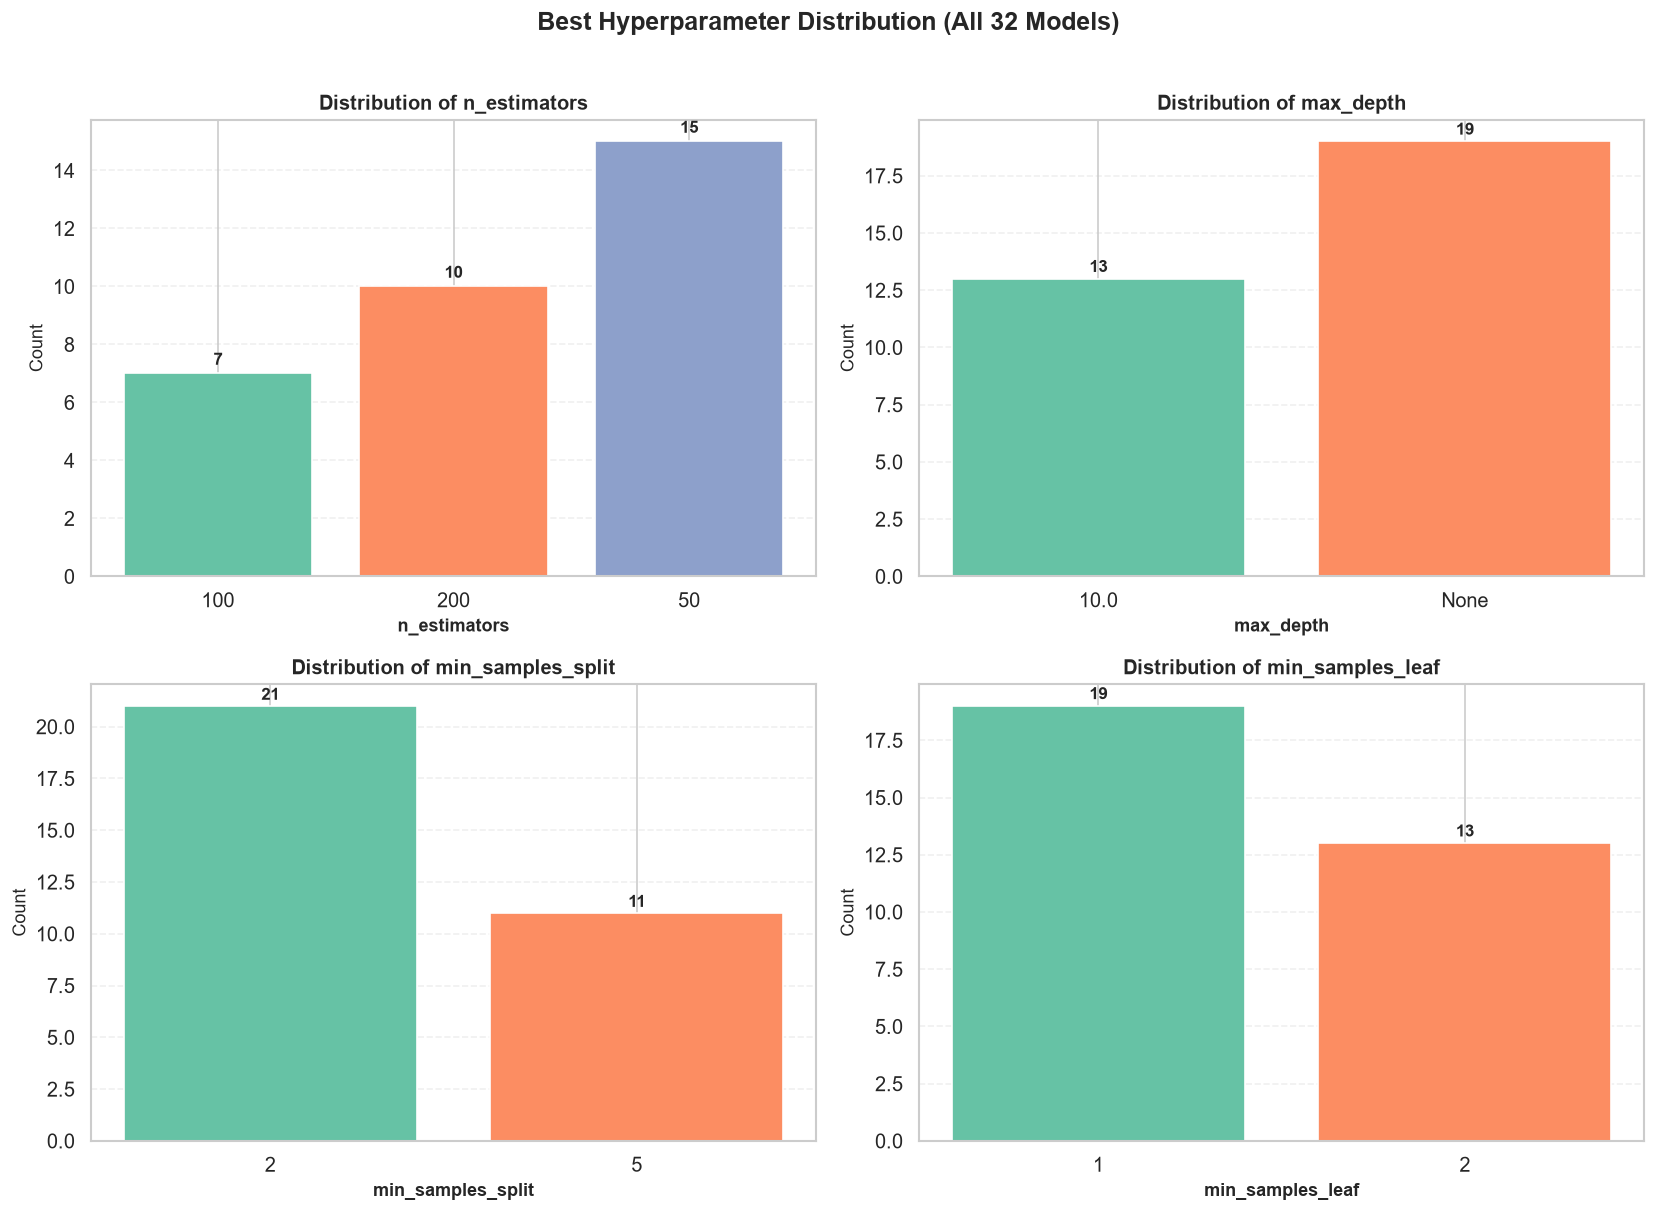

In [52]:
if all_dfs:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Best Hyperparameter Distribution (All 32 Models)',
                 fontsize=15, fontweight='bold', y=1.01)

    hp_names = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']
    hp_labels = ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf']

    for ax, hp, label in zip(axes.flat, hp_names, hp_labels):
        values = df_all[hp].fillna('None').astype(str).value_counts().sort_index()
        colors = sns.color_palette("Set2", len(values))
        bars = ax.bar(values.index, values.values, color=colors, edgecolor='white')
        for bar, val in zip(bars, values.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', fontsize=10, fontweight='bold')
        ax.set_xlabel(label, fontsize=11, fontweight='bold')
        ax.set_ylabel('Count', fontsize=11)
        ax.set_title(f'Distribution of {label}', fontsize=12, fontweight='bold')
        ax.grid(axis='y', alpha=0.3, linestyle='--')

    plt.tight_layout()
    plt.show()

## 15. Accuracy vs Standard Deviation

Higher accuracy with lower variance is ideal (top-left corner). This scatter plot reveals which models are both accurate and stable.

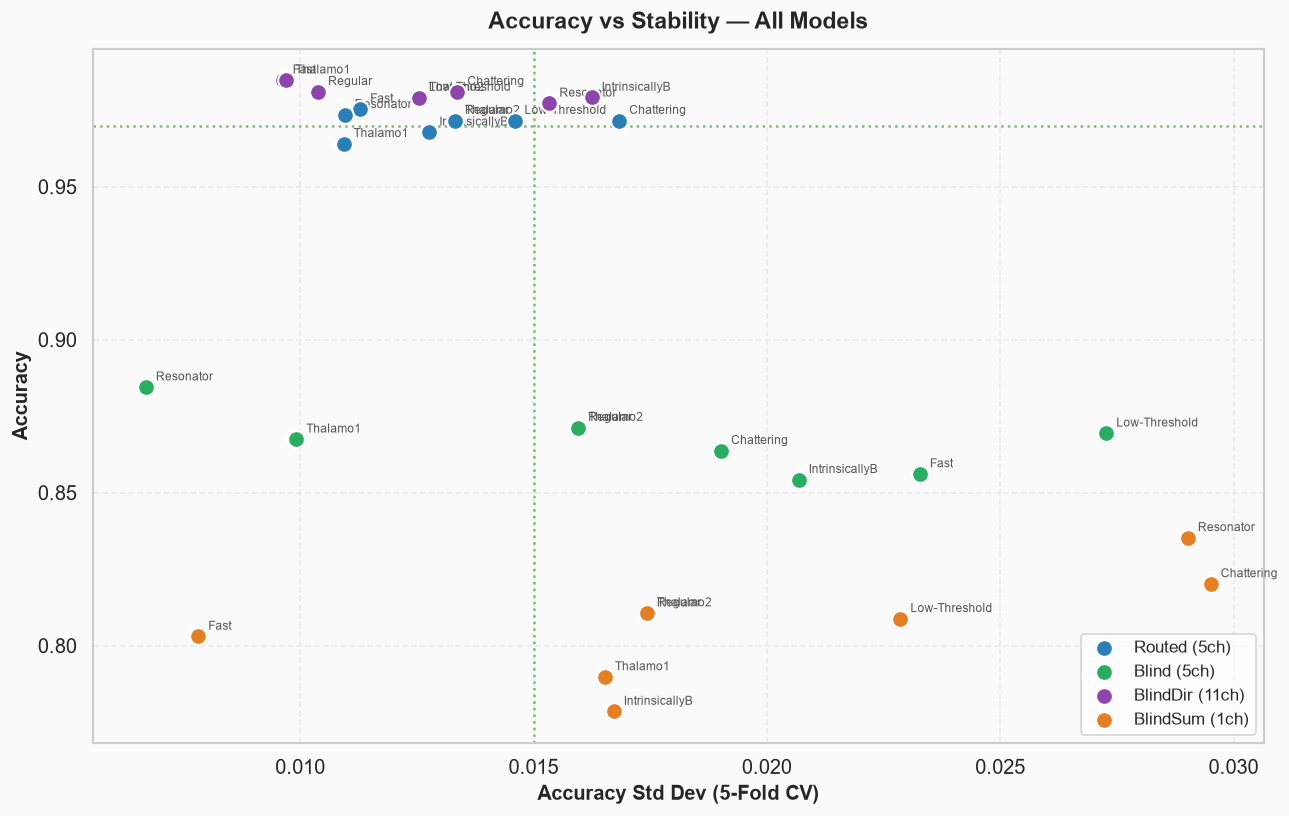

In [53]:
if all_dfs:
    fig, ax = plt.subplots(figsize=(11, 7))
    fig.patch.set_facecolor('#fafafa')
    ax.set_facecolor('#fafafa')

    for label, df in all_dfs.items():
        cfg = next(c for c in TRAIN_CONFIGS if c['label'] == label)
        ax.scatter(df['Acc_Std'], df['Accuracy'],
                   s=100, color=cfg['color'], edgecolors='white',
                   linewidth=1.2, label=f"{label} ({cfg['n_features']}ch)",
                   zorder=4)
        # Annotate with neuron names
        for _, row in df.iterrows():
            ax.annotate(row['Neuron'], (row['Acc_Std'], row['Accuracy']),
                        textcoords='offset points', xytext=(6, 4),
                        fontsize=7, color='#555')

    ax.set_xlabel('Accuracy Std Dev (5-Fold CV)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    ax.set_title('Accuracy vs Stability — All Models',
                 fontsize=14, fontweight='bold', pad=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, linestyle='--')

    # Highlight ideal zone
    ax.axhline(y=0.97, color='green', ls=':', alpha=0.5)
    ax.axvline(x=0.015, color='green', ls=':', alpha=0.5)
    ax.annotate('Ideal zone', xy=(0.005, 0.99), fontsize=10,
                color='green', fontweight='bold', alpha=0.7)

    plt.tight_layout()
    plt.show()

## 16. Configuration Summary — Mean & Best Performance

Aggregate view: mean accuracy, best accuracy, and mean F1 for each configuration.

In [54]:
if all_dfs:
    summary_rows = []
    for label in col_order:
        df = all_dfs[label]
        cfg = next(c for c in TRAIN_CONFIGS if c['label'] == label)
        summary_rows.append({
            'Config': label,
            'Features': cfg['n_features'],
            'Mean Acc': f"{df['Accuracy'].mean():.4f}",
            'Best Acc': f"{df['Accuracy'].max():.4f}",
            'Worst Acc': f"{df['Accuracy'].min():.4f}",
            'Spread': f"{df['Accuracy'].max() - df['Accuracy'].min():.4f}",
            'Mean F1': f"{df['F1_Macro'].mean():.4f}",
            'Best Neuron': df.loc[df['Accuracy'].idxmax(), 'Neuron'],
            'Worst Neuron': df.loc[df['Accuracy'].idxmin(), 'Neuron'],
        })
    summary_table = pd.DataFrame(summary_rows)
    display(summary_table.style.set_caption("Configuration Summary"))

,Config,Features,Mean Acc,Best Acc,Worst Acc,Spread,Mean F1,Best Neuron,Worst Neuron
0,Routed,5,0.9709,0.9754,0.9640,0.0114,0.9709,Fast,Thalamo1
1,Blind,5,0.8672,0.8845,0.8542,0.0302,0.8691,Resonator,IntrinsicallyB
2,BlindDir,11,0.9808,0.9849,0.9773,0.0076,0.9808,Fast,Resonator
3,BlindSum,1,0.8071,0.8352,0.7785,0.0568,0.8057,Resonator,IntrinsicallyB


Calculating aggregated confusion matrix for Blind...
Calculating aggregated confusion matrix for Routed...


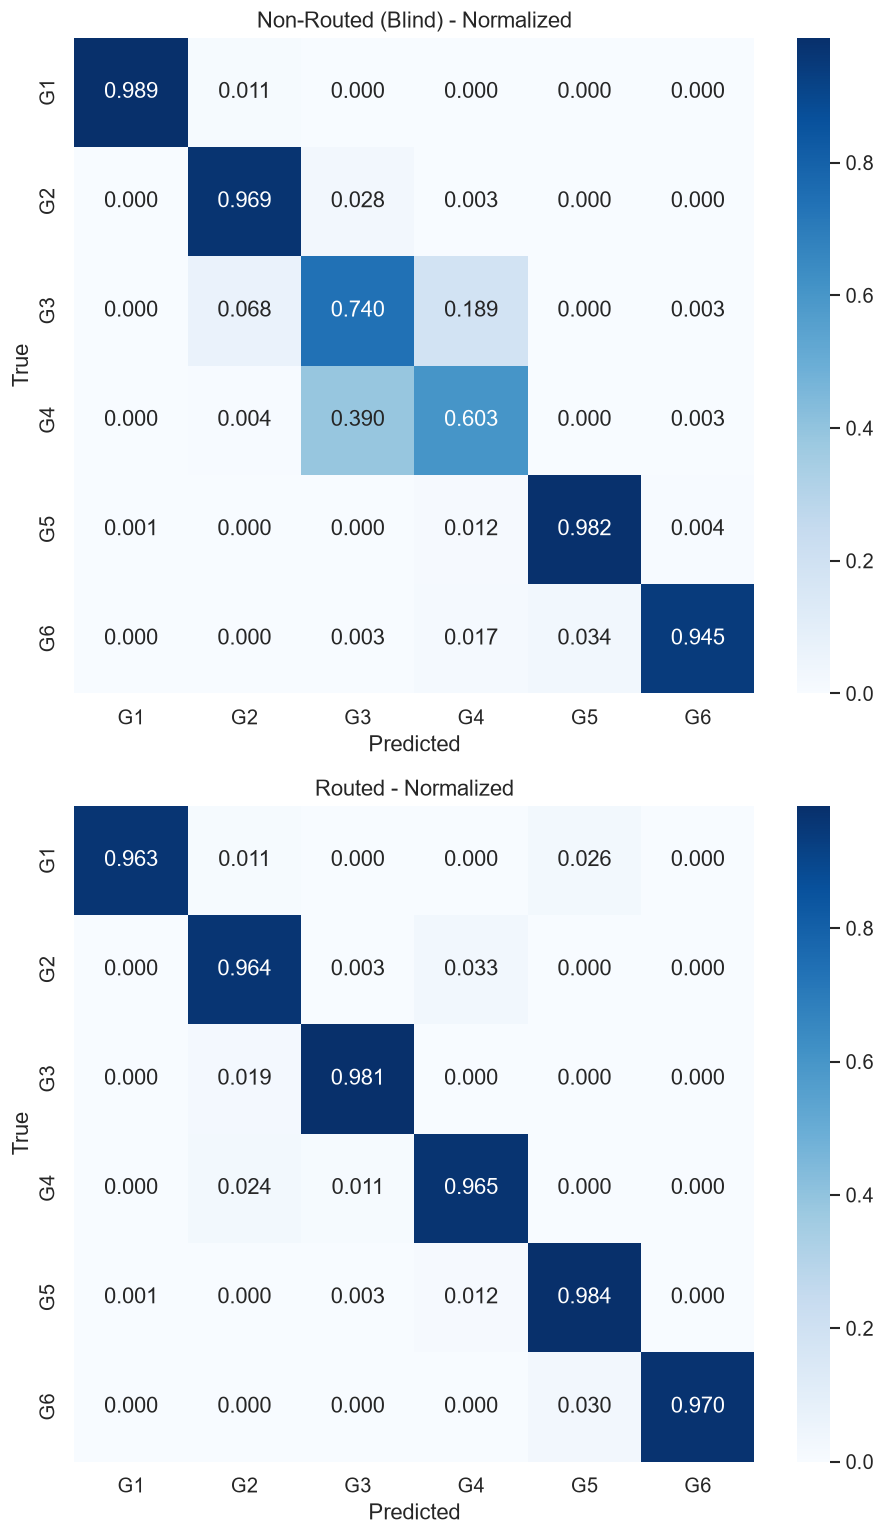

In [56]:
# Matrici di confusione normalizzate per Routed e Blind (in colonna)
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os, glob, pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold

def get_aggregated_cm(config_label):
    print(f'Calculating aggregated confusion matrix for {config_label}...')
    cfg = next(c for c in TRAIN_CONFIGS if c['label'] == config_label)
    df_config = all_dfs[config_label]
    
    if cfg['n_features'] == 11:
        load_fn = load_spike_dataset_11ch
    elif cfg['n_features'] == 1:
        load_fn = load_spike_dataset_1ch_sum
    else:
        load_fn = load_spike_dataset_5ch
        
    files = sorted(glob.glob(os.path.join(cfg['data_dir'], cfg['prefix'] + '*.csv')))
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    
    y_true_all = []
    y_pred_all = []
    
    for filepath in files:
        name = extract_neuron_name(filepath)
        df = load_fn(filepath)
        if len(df) < 5: continue
        
        X = df[cfg['features']].values
        y = df['label'].values
        
        neuron_row = df_config[df_config['Neuron'] == name].iloc[0]
        rf = RandomForestClassifier(
            n_estimators=int(neuron_row['n_estimators']),
            max_depth=None if pd.isna(neuron_row['max_depth']) else int(neuron_row['max_depth']),
            min_samples_split=int(neuron_row['min_samples_split']),
            min_samples_leaf=int(neuron_row['min_samples_leaf']),
            random_state=42, n_jobs=-1, class_weight='balanced'
        )
        
        y_pred = cross_val_predict(rf, X, y, cv=skf, n_jobs=-1)
        y_true_all.extend(y)
        y_pred_all.extend(y_pred)
        
    # Calcolo della matrice di confusione normalizzata (solo per label 1-6)
    cm_norm = confusion_matrix(y_true_all, y_pred_all, labels=[1, 2, 3, 4, 5, 6], normalize='true')
    return cm_norm

# Ottenimento delle matrici
cm_blind = get_aggregated_cm('Blind')
cm_routed = get_aggregated_cm('Routed')

# Plot nella stessa figura, disposte in verticale (2 righe, 1 colonna)
fig, axes = plt.subplots(2, 1, figsize=(8, 13))
labels = ['G1', 'G2', 'G3', 'G4', 'G5', 'G6']

sns.heatmap(cm_blind, annot=True, fmt='.3f', cmap='Blues', ax=axes[0], xticklabels=labels, yticklabels=labels)
axes[0].set_title('Non-Routed (Blind) - Normalized')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_routed, annot=True, fmt='.3f', cmap='Blues', ax=axes[1], xticklabels=labels, yticklabels=labels)
axes[1].set_title('Routed - Normalized')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

